# Auditoría Completa del Dataset — Checklist Pre-Entrenamiento

Este notebook verifica TODOS los puntos críticos antes de entrenar cualquier modelo.
Cada sección termina con un veredicto: ✅ PASA / ⚠ ADVERTENCIA / ❌ FALLA.

## Checklist
- **A.** Balance de positivos por sujeto
- **B.** Balance por distancia temporal al onset
- **C.** Overlap excesivo entre ventanas
- **D.** Negativos alejados del onset
- **E.** NaN en features HRV
- **F.** Distribución por fold LOSO
- **G.** Baseline simple (Logistic Regression + Random Forest)

In [ ]:
import pickle
from scipy import stats as scipy_stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import warnings
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
warnings.filterwarnings('ignore')

WESAD_PATH  = 'WESAD'
SUBJECTS    = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']
FS_10       = 10
WINDOW      = 600    # 60s
STRIDE      = 10     # 1s
STRESS      = 2
NEG_RATIO   = 3
LABEL_NAMES = {1:'Baseline', 2:'Stress', 3:'Amusement', 4:'Meditation'}
PRECURSOR_ZONES = [50, 100, 200, 300]  # 5s, 10s, 20s, 30s
PRECURSOR_ZONE  = 300

# Cargar datasets generados en el pipeline anterior
data_B = np.load(f'{WESAD_PATH}/fase_B_hybrid.npz', allow_pickle=True)
subjects_B = list(data_B['subjects'])

windows_B = {}
for s in subjects_B:
    windows_B[s] = (
        data_B[f'{s}_Xts'],
        data_B[f'{s}_Xhr'],
        data_B[f'{s}_y']
    )

print(f'En total: {len(windows_B)} sujetos')
print(f'Sujetos con transiciones: {subjects_B}')

Dataset Fase B cargado: 15 sujetos
Sujetos con transiciones: [np.str_('S2'), np.str_('S3'), np.str_('S4'), np.str_('S5'), np.str_('S6'), np.str_('S7'), np.str_('S8'), np.str_('S9'), np.str_('S10'), np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17')]


## CHECK A — Balance de positivos/negativos por sujeto

CHECK A — Balance por sujeto
Sujeto    Positivos  Negativos    Total    % pos    Ratio
----------------------------------------------------------------------
S2               30         90      120    25.0%     3.0:1
S3               30         90      120    25.0%     3.0:1
S4               30         90      120    25.0%     3.0:1
S5               30         90      120    25.0%     3.0:1
S6               30         90      120    25.0%     3.0:1
S7               30         90      120    25.0%     3.0:1
S8               30         90      120    25.0%     3.0:1
S9               30         90      120    25.0%     3.0:1
S10              30         90      120    25.0%     3.0:1
S11              30         90      120    25.0%     3.0:1
S13              30         90      120    25.0%     3.0:1
S14              30         90      120    25.0%     3.0:1
S15              30         90      120    25.0%     3.0:1
S16              30         90      120    25.0%     3.0:1
S17             

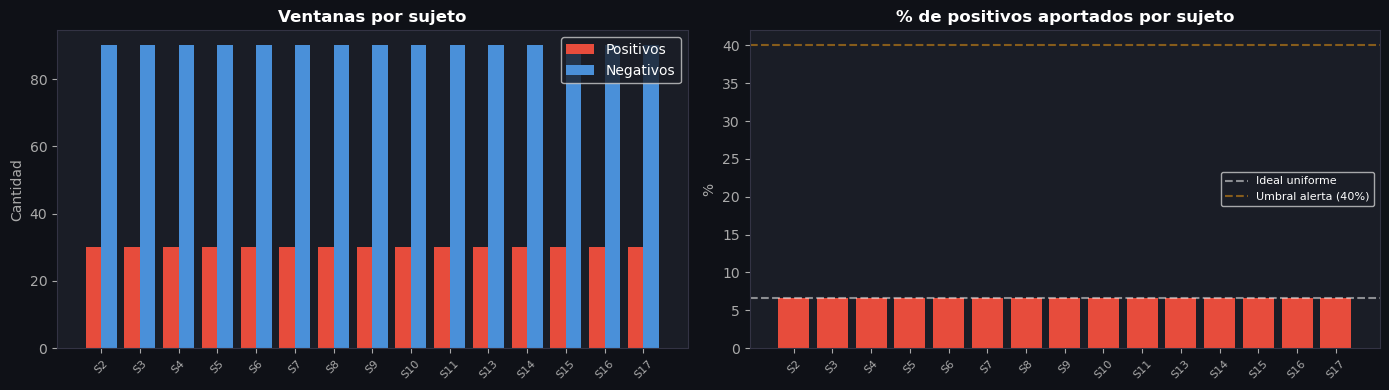

In [ ]:
print('=' * 70)
print('Balance por sujeto')
print('=' * 70)
print(f'{"Sujeto":8} {"Positivos":>10} {"Negativos":>10} {"Total":>8} {"% pos":>8} {"Ratio":>8}')
print('-' * 70)

pos_counts, neg_counts = {}, {}
for s in subjects_B:
    y = windows_B[s][2]
    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    pos_counts[s] = n_pos
    neg_counts[s] = n_neg
    pct  = n_pos / len(y) * 100
    ratio = n_neg / n_pos if n_pos > 0 else float('inf')
    print(f'{s:8} {n_pos:>10} {n_neg:>10} {len(y):>8} {pct:>7.1f}% {ratio:>7.1f}:1')

total_pos = sum(pos_counts.values())
total_neg = sum(neg_counts.values())
print('-' * 70)
print(f'{"TOTAL":8} {total_pos:>10} {total_neg:>10} {total_pos+total_neg:>8}')

# Veredicto
max_pct = max(pos_counts[s]/sum(pos_counts.values())*100 for s in subjects_B)
min_pos = min(pos_counts.values())
print()
if max_pct > 40:
    print(f' Un sujeto aporta {max_pct:.1f}% de los positivos ')
elif min_pos < 5:
    print(f'Algunos sujetos tienen muy pocos positivos ({min_pos})')
else:
    print(f'distribución por sujeto aceptable (máx {max_pct:.1f}%)')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0F1117')
for ax in axes: ax.set_facecolor('#1A1D26')

subs = list(subjects_B)
pos_vals = [pos_counts[s] for s in subs]
neg_vals = [neg_counts[s] for s in subs]
pct_pos  = [pos_counts[s]/sum(pos_counts.values())*100 for s in subs]

x = np.arange(len(subs))
axes[0].bar(x - 0.2, pos_vals, width=0.4, label='Positivos', color='#E74C3C')
axes[0].bar(x + 0.2, neg_vals, width=0.4, label='Negativos', color='#4A90D9')
axes[0].set_xticks(x); axes[0].set_xticklabels(subs, color='#AAAAAA', fontsize=8, rotation=45)
axes[0].set_title('Ventanas por sujeto', color='white', fontweight='bold')
axes[0].tick_params(colors='#AAAAAA'); axes[0].spines[:].set_color('#333344')
axes[0].legend(facecolor='#1A1D26', labelcolor='white')
axes[0].set_ylabel('Cantidad', color='#AAAAAA')

axes[1].bar(subs, pct_pos, color='#E74C3C', edgecolor='none')
axes[1].axhline(y=100/len(subs), color='white', linestyle='--', alpha=0.5, label='Ideal uniforme')
axes[1].axhline(y=40, color='#F39C12', linestyle='--', alpha=0.5, label='Umbral alerta (40%)')
axes[1].set_xticklabels(subs, color='#AAAAAA', fontsize=8, rotation=45)
axes[1].set_title('% de positivos aportados por sujeto', color='white', fontweight='bold')
axes[1].tick_params(colors='#AAAAAA'); axes[1].spines[:].set_color('#333344')
axes[1].legend(facecolor='#1A1D26', labelcolor='white', fontsize=8)
axes[1].set_ylabel('%', color='#AAAAAA')

plt.tight_layout()
plt.show()

## CHECK B — Balance por distancia temporal al onset

CHECK B — Balance por distancia temporal al onset
Distancia al onset     Ventanas  % del total
---------------------------------------------
0-5s                         60        13.8%
10-20s                      150        34.5%
20-30s                      150        34.5%
5-10s                        75        17.2%

✅ CHECK B PASA — positivos distribuidos en distintas distancias temporales


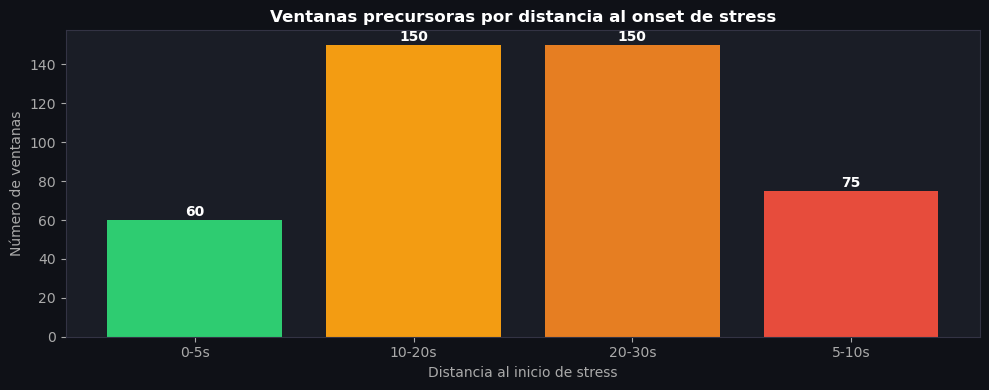

In [ ]:
# porque el npz no guarda la distancia al onset de cada ventana
df_all = pd.read_csv(f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv')

print('=' * 60)
print('Balance por distancia temporal al onset')
print('=' * 60)

# cuántas ventanas positivas caen en cada rango de distancia
bins_seg   = [0, 5, 10, 20, 30]   # segundos
bins_pasos = [b * FS_10 for b in bins_seg]
dist_counts = defaultdict(int)

for subj in subjects_B:
    df_s  = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
    labels = df_s['Label'].values
    onsets = [i for i in range(1, len(labels))
              if labels[i] == STRESS and labels[i-1] != STRESS]

    for onset in onsets:
        zone_end   = onset - 1
        zone_start = max(WINDOW, onset - PRECURSOR_ZONE)
        for end_in in range(zone_start, zone_end + 1, STRIDE):
            start = end_in - WINDOW
            if start < 0: continue
            seg = labels[start:end_in]
            if STRESS in seg or len(set(seg)) > 1: continue
            dist = onset - end_in   # pasos hasta el onset
            dist_seg = dist / FS_10
            for b in range(len(bins_seg)-1):
                if bins_seg[b] <= dist_seg < bins_seg[b+1]:
                    dist_counts[f'{bins_seg[b]}-{bins_seg[b+1]}s'] += 1

print(f'{"Distancia al onset":20} {"Ventanas":>10} {"% del total":>12}')
print('-' * 45)
total_d = sum(dist_counts.values())
for rng, cnt in sorted(dist_counts.items()):
    print(f'{rng:20} {cnt:>10} {cnt/total_d*100:>11.1f}%')

print()
last_bin_pct = dist_counts.get('0-5s', 0) / total_d * 100 if total_d > 0 else 0
if last_bin_pct > 70:
    print(f'{last_bin_pct:.1f}% de positivos están en los últimos 5s — modelo puede aprender stress ya iniciado')
else:
    print(f' positivos distribuidos en distintas distancias temporales')

# Gráfica
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#1A1D26')
rangos = list(sorted(dist_counts.keys()))
vals   = [dist_counts[r] for r in rangos]
ax.bar(rangos, vals, color=['#2ECC71','#F39C12','#E67E22','#E74C3C'], edgecolor='none')
for i, (r, v) in enumerate(zip(rangos, vals)):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', color='white', fontweight='bold')
ax.set_title('Ventanas precursoras por distancia al onset de stress', color='white', fontweight='bold')
ax.set_xlabel('Distancia al inicio de stress', color='#AAAAAA')
ax.set_ylabel('Número de ventanas', color='#AAAAAA')
ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
plt.tight_layout(); plt.show()

## CHECK C — Overlap excesivo entre ventanas

In [ ]:
print('=' * 60)
print('ventanas consecutivas')
print('=' * 60)

# Con WINDOW=600 y STRIDE=10:
# overlap = (WINDOW - STRIDE) / WINDOW * 100
overlap_pct = (WINDOW - STRIDE) / WINDOW * 100
print(f'Window={WINDOW} pasos | Stride={STRIDE} pasos')
print(f'Overlap entre ventanas consecutivas: {overlap_pct:.1f}%')
print(f'Pasos únicos nuevos por ventana: {STRIDE} ({STRIDE/FS_10:.1f}s)')
print()

# Dos ventanas con 98.3% de solapamiento son casi idénticas
# Esto puede inflar el N sin añadir información real
print('Comparación de strides:')
print(f'{"Stride":>10} {"Overlap":>10} {"Ventanas aprox (total)":>24} {"Correlación esperada":>22}')
print('-' * 70)
for s in [10, 30, 50, 100]:
    ov  = (WINDOW - s) / WINDOW * 100
    est = total_pos * (PRECURSOR_ZONE // s)
    corr = 1 - s/WINDOW
    flag = ' ← actual' if s == STRIDE else ''
    print(f'{s:>10} {ov:>9.1f}% {est:>24,} {corr:>21.3f}{flag}')

print()
if overlap_pct > 95:
    print(f'overlap {overlap_pct:.1f}% es muy alto.')
    print(' Considera experimentar con stride=50 (5s) para entrenamiento inicial.')
    print(' El modelo puede aprender mejor con menos ventanas más independientes.')
else:
    print(f'CHECK C PASA')

CHECK C — Overlap entre ventanas consecutivas
Window=600 pasos | Stride=10 pasos
Overlap entre ventanas consecutivas: 98.3%
Pasos únicos nuevos por ventana: 10 (1.0s)

Comparación de strides:
    Stride    Overlap   Ventanas aprox (total)   Correlación esperada
----------------------------------------------------------------------
        10      98.3%                   13,500                 0.983 ← actual
        30      95.0%                    4,500                 0.950
        50      91.7%                    2,700                 0.917
       100      83.3%                    1,350                 0.833

⚠  ADVERTENCIA: overlap 98.3% es muy alto.
   Considera experimentar con stride=50 (5s) para entrenamiento inicial.
   El modelo puede aprender mejor con menos ventanas más independientes.


## CHECK D — Negativos alejados del onset

In [ ]:
print('=' * 60)
print(' Negativos NO cercanos al onset')
print('=' * 60)

# Verificar que ningún negativo esté dentro de la zona que no
# pero lo validamos estadísticamente

# Reconstruir y contar, por sujeto, qué etiqueta tiene cada negativo
neg_label_dist = defaultdict(int)
total_neg_checked = 0

for subj in subjects_B:
    df_s   = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
    labels = df_s['Label'].values
    onsets = [i for i in range(1, len(labels))
              if labels[i] == STRESS and labels[i-1] != STRESS]
    if not onsets: continue

    forbidden = np.zeros(len(labels), dtype=bool)
    for onset in onsets:
        f_start = max(0, onset - PRECURSOR_ZONE)
        f_end   = onset
        while f_end < len(labels) and labels[f_end] == STRESS:
            f_end += 1
        forbidden[f_start:f_end] = True

    for start in range(0, len(labels) - WINDOW + 1, STRIDE * 5):
        end_in = start + WINDOW
        if forbidden[start:end_in].any(): continue
        seg = labels[start:end_in]
        if len(set(seg)) > 1 or seg[0] == STRESS: continue
        neg_label_dist[LABEL_NAMES.get(seg[0], str(seg[0]))] += 1
        total_neg_checked += 1

print('Distribución de etiquetas en negativos:')
for lbl, cnt in sorted(neg_label_dist.items(), key=lambda x: -x[1]):
    print(f'  {lbl:15}: {cnt:>6} ({cnt/total_neg_checked*100:.1f}%)')

stress_in_neg = neg_label_dist.get('Stress', 0)
print()
if stress_in_neg > 0:
    print(f' {stress_in_neg} negativos son de clase Stress ')
else:
    print('ningún negativo contiene stress')
    amusement_pct = neg_label_dist.get('Amusement', 0) / total_neg_checked * 100
    meditation_pct = neg_label_dist.get('Meditation', 0) / total_neg_checked * 100
    if amusement_pct < 5 and meditation_pct < 5:
        print(' Los negativos son casi todos Baseline')
    else:
        print(' Baseline + Amusement + Meditation')

CHECK D — Negativos NO cercanos al onset
Distribución de etiquetas en negativos:
  Baseline       :   2412 (45.4%)
  Meditation     :   1964 (37.0%)
  Amusement      :    938 (17.7%)

✅ CHECK D PASA — ningún negativo contiene stress
✅ Negativos variados: Baseline + Amusement + Meditation


## CHECK E — NaN en features HRV

In [ ]:
print('=' * 60)
print(' NaN en features HRV')
print('=' * 60)
print(f'{"Sujeto":8} {"Total":>8} {"NaN HR":>8} {"NaN RMSSD":>10} {"NaN pNN50":>10} {"% NaN":>8}')
print('-' * 60)

total_nan, total_muestras = 0, 0
for subj in subjects_B:
    X_hrv = windows_B[subj][1]   # shape (n, 3)
    n     = len(X_hrv)
    nan_hr    = np.isnan(X_hrv[:, 0]).sum()
    nan_rmssd = np.isnan(X_hrv[:, 1]).sum()
    nan_pnn50 = np.isnan(X_hrv[:, 2]).sum()
    any_nan   = np.isnan(X_hrv).any(axis=1).sum()
    pct       = any_nan / n * 100
    total_nan += any_nan
    total_muestras += n
    flag = ' ⚠' if pct > 20 else ''
    print(f'{subj:8} {n:>8} {nan_hr:>8} {nan_rmssd:>10} {nan_pnn50:>10} {pct:>7.1f}%{flag}')

global_nan_pct = total_nan / total_muestras * 100
print('-' * 60)
print(f'{"TOTAL":8} {total_muestras:>8} {"":>8} {"":>10} {"":>10} {global_nan_pct:>7.1f}%')
print()
if global_nan_pct > 30:
    print(f' {global_nan_pct:.1f}% NaN es demasiado — revisar detección de picos R')
elif global_nan_pct > 10:
    print(f' {global_nan_pct:.1f}% NaN — se reemplazarán por 0 ')
    print('   Verificar que la detección de picos funciona correctamente en esos sujetos')
else:
    print(f' {global_nan_pct:.1f}% NaN es aceptable')

CHECK E — NaN en features HRV
Sujeto      Total   NaN HR  NaN RMSSD  NaN pNN50    % NaN
------------------------------------------------------------
S2            120        0          0          0     0.0%
S3            120        0          0          0     0.0%
S4            120        0          0          0     0.0%
S5            120        0          0          0     0.0%
S6            120        0          0          0     0.0%
S7            120        0          0          0     0.0%
S8            120        0          0          0     0.0%
S9            120        0          0          0     0.0%
S10           120        0          0          0     0.0%
S11           120        0          0          0     0.0%
S13           120        0          0          0     0.0%
S14           120        0          0          0     0.0%
S15           120        0          0          0     0.0%
S16           120        0          0          0     0.0%
S17           120        0          0  

## CHECK F — Distribución por fold LOSO

CHECK F — Distribución por fold LOSO (Fase B)
Test    Train pos  Train neg   Test pos   Test neg   CW pos   Viable
---------------------------------------------------------------------------
S2            420       1260         30         90     2.00        ✅
S3            420       1260         30         90     2.00        ✅
S4            420       1260         30         90     2.00        ✅
S5            420       1260         30         90     2.00        ✅
S6            420       1260         30         90     2.00        ✅
S7            420       1260         30         90     2.00        ✅
S8            420       1260         30         90     2.00        ✅
S9            420       1260         30         90     2.00        ✅
S10           420       1260         30         90     2.00        ✅
S11           420       1260         30         90     2.00        ✅
S13           420       1260         30         90     2.00        ✅
S14           420       1260         30         90

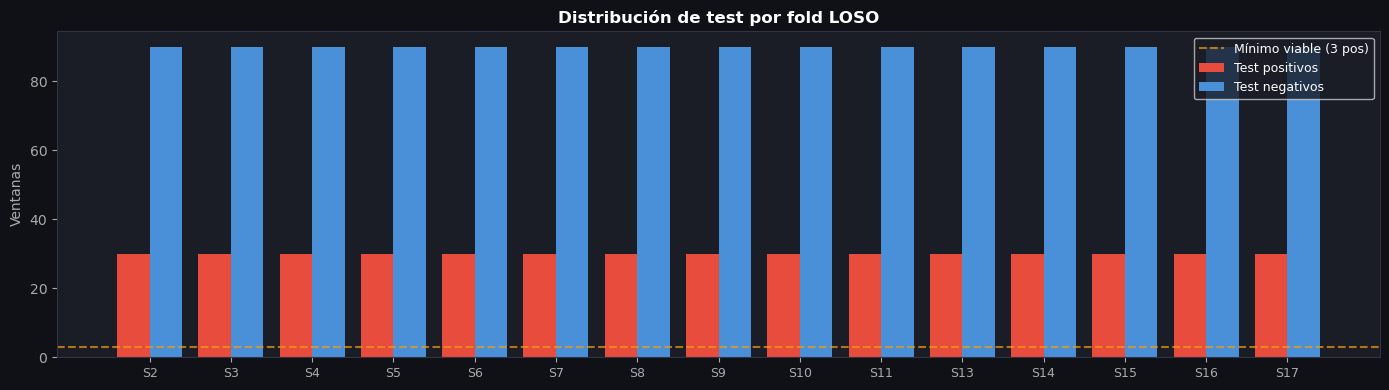

In [ ]:
print('=' * 75)
print(' Distribución por fold LOSO')
print('=' * 75)
print(f'{"Test":6} {"Train pos":>10} {"Train neg":>10} {"Test pos":>10} {"Test neg":>10} {"CW pos":>8} {"Viable":>8}')
print('-' * 75)

folds_inviables = []
for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]
    y_tr = np.concatenate([windows_B[s][2] for s in train_subjs])
    y_te = windows_B[test_subj][2]

    tr_pos = (y_tr == 1).sum()
    tr_neg = (y_tr == 0).sum()
    te_pos = (y_te == 1).sum()
    te_neg = (y_te == 0).sum()

    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    cw_pos  = dict(zip(classes, weights)).get(1, 0)

    viable = 'bien' if te_pos >= 3 else 'mal'
    if te_pos < 3:
        folds_inviables.append(test_subj)
    print(f'{test_subj:6} {tr_pos:>10} {tr_neg:>10} {te_pos:>10} {te_neg:>10} {cw_pos:>8.2f} {viable:>8}')

print()
if folds_inviables:
    print(f'folds {folds_inviables} tienen < 3 positivos en test')
    print(' Esos folds se excluirán del promedio final o se reportarán por separado')
else:
    print(' todos los folds tienen positivos suficientes en test')

# Gráfica de distribución por fold
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0F1117'); ax.set_facecolor('#1A1D26')
x = np.arange(len(subjects_B))
te_pos_vals = [(windows_B[s][2] == 1).sum() for s in subjects_B]
te_neg_vals = [(windows_B[s][2] == 0).sum() for s in subjects_B]
ax.bar(x - 0.2, te_pos_vals, width=0.4, label='Test positivos', color='#E74C3C')
ax.bar(x + 0.2, te_neg_vals, width=0.4, label='Test negativos', color='#4A90D9')
ax.axhline(y=3, color='#F39C12', linestyle='--', alpha=0.7, label='Mínimo viable (3 pos)')
ax.set_xticks(x); ax.set_xticklabels(subjects_B, color='#AAAAAA', fontsize=9)
ax.set_title('Distribución de test por fold LOSO', color='white', fontweight='bold')
ax.tick_params(colors='#AAAAAA'); ax.spines[:].set_color('#333344')
ax.legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
ax.set_ylabel('Ventanas', color='#AAAAAA')
plt.tight_layout(); plt.show()

## CHECK G — Baseline simple interpretable

Antes de LSTM, verificamos si el problema es detectable
con modelos simples. Si Logistic Regression ya funciona,
tenemos evidencia de que las features capturan señal real.

Features usadas: estadísticas por señal (media, std, slope, min, max) + HRV.

In [ ]:
def extract_stats_features(X_ts, X_hrv):
    """
    Extrae features estadísticas de la serie temporal.
    Cada ventana (600, 3) → vector de features.
    Features: mean, std, min, max, slope por señal + HRV
    """
    n = len(X_ts)
    n_signals = X_ts.shape[2]
    t = np.arange(X_ts.shape[1])
    feats = []
    for i in range(n):
        row = []
        for s in range(n_signals):
            sig = X_ts[i, :, s]
            row += [
                sig.mean(), sig.std(), sig.min(), sig.max(),
                np.percentile(sig, 25), np.percentile(sig, 75),
                np.polyfit(t, sig, 1)[0]  # slope (tendencia)
            ]
        row += list(X_hrv[i])  # HR_mean, RMSSD, pNN50
        feats.append(row)
    return np.array(feats, dtype=np.float32)


print('=' * 60)
print('Baseline LOSO completo (Regresión Logisticax + RF)')
print('=' * 60)

auc_lr, auc_rf = [], []
print(f'{"Fold":8} {"AUC LR":>10} {"AUC RF":>10}')
print('-' * 32)

for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]

    X_ts_tr  = np.concatenate([windows_B[s][0] for s in train_subjs])
    X_hrv_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr     = np.concatenate([windows_B[s][2] for s in train_subjs])
    X_ts_te, X_hrv_te, y_te = windows_B[test_subj]

    if (y_te == 1).sum() < 2:
        print(f'{test_subj:8} {"skip (< 2 pos)":>10}')
        continue

    # Normalizar HRV con stats de train
    hrv_mean = np.nanmean(X_hrv_tr, axis=0)
    hrv_std  = np.nanstd(X_hrv_tr,  axis=0) + 1e-8
    X_hrv_tr = np.nan_to_num((X_hrv_tr - hrv_mean) / hrv_std, nan=0.0)
    X_hrv_te = np.nan_to_num((X_hrv_te - hrv_mean) / hrv_std, nan=0.0)

    F_tr = extract_stats_features(X_ts_tr, X_hrv_tr)
    F_te = extract_stats_features(X_ts_te, X_hrv_te)

    # Reemplazar NaN restantes
    col_means = np.nanmean(F_tr, axis=0)
    for c in range(F_tr.shape[1]):
        F_tr[np.isnan(F_tr[:, c]), c] = col_means[c]
        F_te[np.isnan(F_te[:, c]), c] = col_means[c]

    # Logistic Regression
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(F_tr, y_tr)
    prob_lr = lr.predict_proba(F_te)[:, 1]
    auc_l   = roc_auc_score(y_te, prob_lr) if len(np.unique(y_te)) > 1 else float('nan')

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    rf.fit(F_tr, y_tr)
    prob_rf = rf.predict_proba(F_te)[:, 1]
    auc_r   = roc_auc_score(y_te, prob_rf) if len(np.unique(y_te)) > 1 else float('nan')

    auc_lr.append(auc_l)
    auc_rf.append(auc_r)
    print(f'{test_subj:8} {auc_l:>10.3f} {auc_r:>10.3f}')

auc_lr_arr = np.array([x for x in auc_lr if not np.isnan(x)])
auc_rf_arr = np.array([x for x in auc_rf if not np.isnan(x)])
print('-' * 32)
print(f'{"Media":8} {auc_lr_arr.mean():>10.3f} {auc_rf_arr.mean():>10.3f}')
print(f'{"Std":8} {auc_lr_arr.std():>10.3f} {auc_rf_arr.std():>10.3f}')

print()
media_rf = auc_rf_arr.mean()
if media_rf > 0.70:
    print(f'RF AUC={media_rf:.3f} — señal real detectable con modelo simple')
    print('   LSTM debería superar este baseline. Si no lo supera, revisar features.')
elif media_rf > 0.55:
    print(f'  AUC={media_rf:.3f} — señal débil pero presente. LSTM puede mejorar con contexto temporal.')
else:
    print(f' AUC={media_rf:.3f} — casi aleatorio. Revisar construcción de labels antes de entrenar.')

CHECK G — Baseline LOSO completo (Logistic Regression + RF)
Fold         AUC LR     AUC RF
--------------------------------
S2            0.411      0.280
S3            0.781      0.857
S4            0.880      0.846
S5            0.453      0.305
S6            0.524      0.447
S7            0.695      0.932
S8            0.642      0.538
S9            0.416      0.927
S10           0.876      0.808
S11           0.715      0.589
S13           0.434      0.922
S14           0.859      0.834
S15           0.197      0.094
S16           0.713      0.300
S17           0.670      0.866
--------------------------------
Media         0.618      0.636
Std           0.196      0.278

⚠  AUC=0.636 — señal débil pero presente. LSTM puede mejorar con contexto temporal.


## Resumen final de la auditoría

In [ ]:
print('=' * 60)
print('RESUMEN DE AUDITORÍA')
print('=' * 60)
print()
print('Interpreta cada check y llena la tabla:')
print()
checks = [
    ('A', 'Balance por sujeto',               'Ver salida de check A'),
    ('B', 'Balance por distancia temporal',    'Ver salida de check B'),
    ('C', 'Overlap entre ventanas',            f'Overlap={overlap_pct:.1f}% — considerar stride=50'),
    ('D', 'Negativos alejados del onset',      'Ver salida de check D'),
    ('E', 'NaN en HRV',                        f'Global NaN={global_nan_pct:.1f}%'),
    ('F', 'Distribución por fold LOSO',        f'Folds inviables: {folds_inviables}'),
    ('G', 'Baseline simple (AUC)',             f'RF AUC={media_rf:.3f}'),
]
print(f'{"Check":6} {"Descripción":35} {"Observación"}')
print('-' * 75)
for chk, desc, obs in checks:
    print(f'{chk:6} {desc:35} {obs}')

print()
print('DECISIÓN:')
if media_rf > 0.55 and global_nan_pct < 30 and len(folds_inviables) < 3:
    print(' Dataset suficientemente validado para avanzar a entrenamiento.')
    print('   Siguiente paso: LSTM híbrido Fase A (baseline), luego Fase B.')
else:
    print(' Hay issues que resolver antes de entrenar. Ver checks marcados con ⚠ o ❌.')

RESUMEN DE AUDITORÍA

Interpreta cada check y llena la tabla:

Check  Descripción                         Observación
---------------------------------------------------------------------------
A      Balance por sujeto                  Ver salida de check A
B      Balance por distancia temporal      Ver salida de check B
C      Overlap entre ventanas              Overlap=98.3% — considerar stride=50
D      Negativos alejados del onset        Ver salida de check D
E      NaN en HRV                          Global NaN=0.0%
F      Distribución por fold LOSO          Folds inviables: []
G      Baseline simple (AUC)               RF AUC=0.636

DECISIÓN:
✅ Dataset suficientemente validado para avanzar a entrenamiento.
   Siguiente paso: LSTM híbrido Fase A (baseline), luego Fase B.
